# 分类树

本实验使用 `scikit-learn` 的乳腺癌二分类数据考察决策树的复杂度控制。实验依次完成：

1. 将恶性样本定义为正类，并划分训练集与独立测试集；
2. 拟合不限制复杂度的分类树，观察训练集与测试集表现的差距；
3. 利用训练集上的五折分层交叉验证选择 `max_depth` 与 `min_samples_leaf`；
4. 在测试集上报告 Accuracy、Precision、Recall、F1 与 AUROC，并查看混淆矩阵和特征重要性。


In [1]:
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib

configure_matplotlib()

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier

plt.style.use("seaborn-v0_8-white")
RANDOM_STATE = 42
COLORS = {"unrestricted": "#E45756", "tuned": "#4C78A8"}


## 1. 预处理

原始数据将良性记为 $1$、恶性记为 $0$。为使疾病筛查中的 Recall 具有直接含义，这里重新编码为恶性 $=1$、良性 $=0$。先按类别比例划出 $20\%$ 的独立测试集，其余 $80\%$ 作为训练集。


In [2]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series((cancer.target == 0).astype(int), name="malignant")

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

data_summary = pd.Series(
    {
        "total samples": len(X),
        "features": X.shape[1],
        "train samples": len(X_dev),
        "test samples": len(X_test),
        "malignant rate": y.mean(),
    },
    name="value",
).to_frame()
class_counts = pd.DataFrame(
    {
        "train": y_dev.value_counts().sort_index(),
        "test": y_test.value_counts().sort_index(),
    }
).rename(index={0: "benign (0)", 1: "malignant (1)"})
display(data_summary.round(3))
display(class_counts)


,value
total samples,569.000
features,30.000
train samples,455.000
test samples,114.000
malignant rate,0.373


,train,test
malignant,,
benign (0),285,72
malignant (1),170,42


## 2. 不限制树生长

令 `max_depth=None`、`min_samples_leaf=1`，使树一直生长到叶节点纯净或无法继续分裂，查看模型的拟合情况。


In [3]:
def classification_metrics(model, features, labels):
    prediction = model.predict(features)
    probability = model.predict_proba(features)[:, 1]
    return {
        "Accuracy": accuracy_score(labels, prediction),
        "Precision": precision_score(labels, prediction),
        "Recall": recall_score(labels, prediction),
        "F1": f1_score(labels, prediction),
        "AUROC": roc_auc_score(labels, probability),
    }

unrestricted = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_dev, y_dev)
unrestricted_metrics = pd.DataFrame(
    {
        "train": classification_metrics(unrestricted, X_dev, y_dev),
        "test": classification_metrics(unrestricted, X_test, y_test),
    }
).T
unrestricted_structure = pd.Series(
    {
        "depth": unrestricted.get_depth(),
        "leaves": unrestricted.get_n_leaves(),
    },
    name="unrestricted tree",
).to_frame()
display(unrestricted_structure)
display(unrestricted_metrics.round(3))


,unrestricted tree
depth,8
leaves,24


,Accuracy,Precision,Recall,F1,AUROC
train,1.00,1.000,1.000,1.000,1.000
test,0.93,0.905,0.905,0.905,0.925


## 3. 观察树深的影响

固定 `min_samples_leaf=1`，令 `max_depth` 从 $1$ 增加到 $12$。每个候选深度都在训练集上进行相同的五折分层交叉验证。训练 AUROC 与交叉验证 AUROC 的分离可以显示模型复杂度增加后方差逐渐增大的过程。


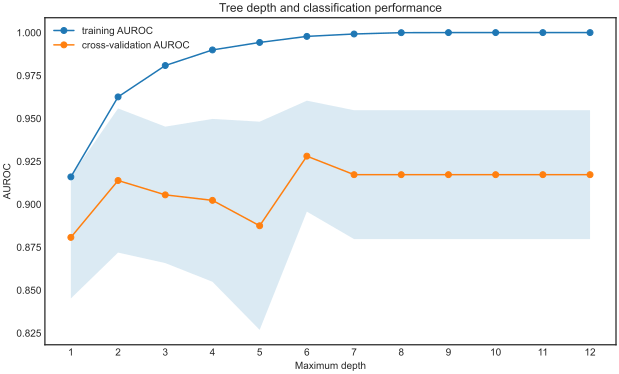

In [4]:
classification_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
depth_rows = []
for depth in range(1, 13):
    scores = cross_validate(
        DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE),
        X_dev,
        y_dev,
        scoring="roc_auc",
        cv=classification_cv,
        return_train_score=True,
        n_jobs=1,
    )
    depth_rows.append(
        {
            "max_depth": depth,
            "training AUROC": scores["train_score"].mean(),
            "validation AUROC": scores["test_score"].mean(),
            "validation standard deviation": scores["test_score"].std(),
        }
    )
depth_results = pd.DataFrame(depth_rows).set_index("max_depth")

fig, ax = plt.subplots(figsize=(8.6, 5.2), constrained_layout=True)
ax.plot(depth_results.index, depth_results["training AUROC"], marker="o", label="training AUROC")
ax.plot(depth_results.index, depth_results["validation AUROC"], marker="o", label="cross-validation AUROC")
ax.fill_between(
    depth_results.index,
    depth_results["validation AUROC"] - depth_results["validation standard deviation"],
    depth_results["validation AUROC"] + depth_results["validation standard deviation"],
    alpha=0.16,
)
ax.set(
    title="Tree depth and classification performance",
    xlabel="Maximum depth",
    ylabel="AUROC",
    xticks=list(depth_results.index),
)
ax.legend()
plt.show()


## 4. 调参

联合搜索上述两个参数的最优值，并以平均交叉验证 AUROC 最大作为选择准则，若平均交叉验证 AUROC 相同，则取复杂度最低的模型。


,max_depth,min_samples_leaf,training AUROC,validation AUROC,validation standard deviation
39,None,20,0.988,0.959,0.021
34,8,20,0.988,0.959,0.021
29,6,20,0.988,0.959,0.021
24,5,20,0.988,0.959,0.021
19,4,20,0.988,0.958,0.022
28,6,10,0.992,0.956,0.021
23,5,10,0.992,0.956,0.021
33,8,10,0.992,0.956,0.021


Selected parameters: {'max_depth': 5, 'min_samples_leaf': 20}
Mean cross-validation AUROC: 0.959


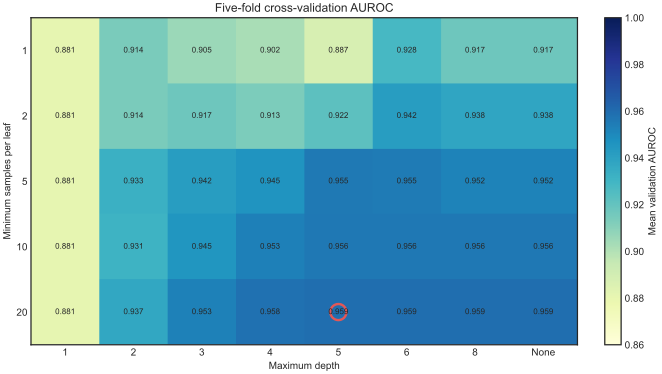

In [5]:
depth_values = [1, 2, 3, 4, 5, 6, 8, None]
leaf_values = [1, 2, 5, 10, 20]
classification_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid={
        "max_depth": depth_values,
        "min_samples_leaf": leaf_values,
    },
    scoring="roc_auc",
    cv=classification_cv,
    return_train_score=True,
    n_jobs=1,
)
classification_grid.fit(X_dev, y_dev)

classification_cv_results = pd.DataFrame(classification_grid.cv_results_)
classification_cv_results["depth label"] = classification_cv_results["param_max_depth"].map(
    lambda value: "None" if value is None else str(int(value))
)
classification_heatmap = classification_cv_results.pivot(
    index="param_min_samples_leaf",
    columns="depth label",
    values="mean_test_score",
).reindex(index=leaf_values, columns=[str(value) for value in depth_values[:-1]] + ["None"])
top_classification_settings = (
    classification_cv_results[
        ["depth label", "param_min_samples_leaf", "mean_train_score", "mean_test_score", "std_test_score"]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(8)
    .rename(
        columns={
            "depth label": "max_depth",
            "param_min_samples_leaf": "min_samples_leaf",
            "mean_train_score": "training AUROC",
            "mean_test_score": "validation AUROC",
            "std_test_score": "validation standard deviation",
        }
    )
)
display(top_classification_settings.round(3))
print(f"Selected parameters: {classification_grid.best_params_}")
print(f"Mean cross-validation AUROC: {classification_grid.best_score_:.3f}")

fig, ax = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)
image = ax.imshow(classification_heatmap.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0.86, vmax=1.00)
for row in range(classification_heatmap.shape[0]):
    for column in range(classification_heatmap.shape[1]):
        value = classification_heatmap.iloc[row, column]
        ax.text(column, row, f"{value:.3f}", ha="center", va="center", fontsize=8)
best_depth_label = (
    "None" if classification_grid.best_params_["max_depth"] is None
    else str(classification_grid.best_params_["max_depth"])
)
best_column = list(classification_heatmap.columns).index(best_depth_label)
best_row = list(classification_heatmap.index).index(classification_grid.best_params_["min_samples_leaf"])
ax.scatter(best_column, best_row, s=260, facecolors="none", edgecolors="#E45756", linewidths=2.4)
ax.set(
    title="Five-fold cross-validation AUROC",
    xlabel="Maximum depth",
    ylabel="Minimum samples per leaf",
    xticks=np.arange(classification_heatmap.shape[1]),
    xticklabels=classification_heatmap.columns,
    yticks=np.arange(classification_heatmap.shape[0]),
    yticklabels=classification_heatmap.index,
)
fig.colorbar(image, ax=ax, label="Mean validation AUROC")
plt.show()


## 5. 在测试集上比较模型

调参结束后才使用测试集。分类指标采用阈值 $0.5$，AUROC 则直接使用叶节点中的恶性样本比例。混淆矩阵的行表示真实类别，列表示预测类别。


depth  leaves  Accuracy  Precision  Recall     F1  AUROC
model        data                                                           
unrestricted train      8      24     1.000      1.000   1.000  1.000  1.000
             test       8      24     0.930      0.905   0.905  0.905  0.925
tuned        train      5       7     0.941      0.899   0.947  0.923  0.988
             test       5       7     0.939      0.927   0.905  0.916  0.979

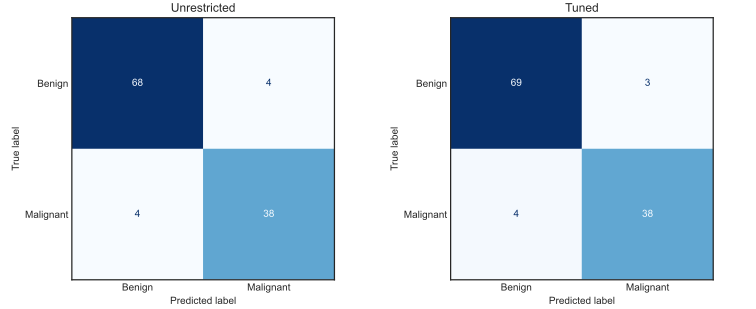

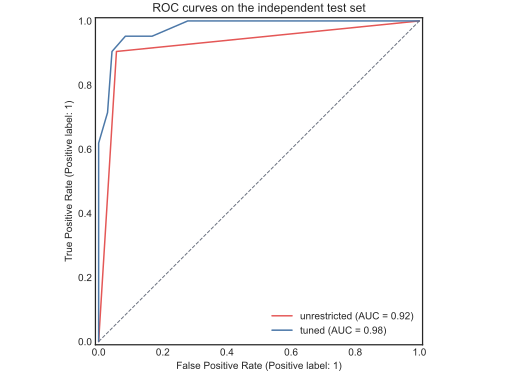

In [6]:
tuned_classifier = classification_grid.best_estimator_
classification_models = {
    "unrestricted": unrestricted,
    "tuned": tuned_classifier,
}
comparison_rows = []
for model_name, model in classification_models.items():
    for data_name, features, labels in [
        ("train", X_dev, y_dev),
        ("test", X_test, y_test),
    ]:
        comparison_rows.append(
            {
                "model": model_name,
                "data": data_name,
                "depth": model.get_depth(),
                "leaves": model.get_n_leaves(),
                **classification_metrics(model, features, labels),
            }
        )
classification_comparison = pd.DataFrame(comparison_rows).set_index(["model", "data"])
display(classification_comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), constrained_layout=True)
for ax, (model_name, model) in zip(axes, classification_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        model.predict(X_test),
        display_labels=["Benign", "Malignant"],
        colorbar=False,
        cmap="Blues",
        ax=ax,
    )
    ax.set_title(model_name.capitalize())
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
for model_name, model in classification_models.items():
    RocCurveDisplay.from_predictions(
        y_test,
        model.predict_proba(X_test)[:, 1],
        name=model_name,
        curve_kwargs={"color": COLORS[model_name]},
        ax=ax,
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="#6B7280", linewidth=1)
ax.set_title("ROC curves on the independent test set")
plt.show()


## 6. 基于不纯度下降的特征重要性

下面给出调参后分类树中得分最高的十个特征。


,importance
worst perimeter,0.872
worst concave points,0.111
area error,0.012
worst texture,0.004
worst radius,0.001
mean radius,0.000
concavity error,0.000
worst symmetry,0.000
worst concavity,0.000
worst compactness,0.000


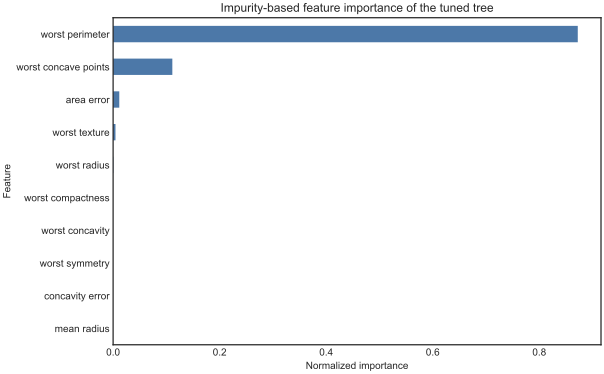

In [7]:
feature_importance = (
    pd.Series(tuned_classifier.feature_importances_, index=X.columns, name="importance")
    .sort_values(ascending=False)
    .head(10)
)
display(feature_importance.to_frame().round(3))

fig, ax = plt.subplots(figsize=(8.4, 5.2), constrained_layout=True)
feature_importance.sort_values().plot.barh(ax=ax, color="#4C78A8")
ax.set(
    title="Impurity-based feature importance of the tuned tree",
    xlabel="Normalized importance",
    ylabel="Feature",
)
plt.show()
